# Batching raw ultrasound data with `zea.Dataloader`

`zea.Dataloader` turns a folder of zea files into a batched, shuffled, multi-threaded stream of
samples, ready for a training loop. It is built on [Grain](https://github.com/google/grain).

Most dataloader examples use images, but channel data (`raw_data`) is where the loader earns its
keep: the arrays are five-dimensional and large, so *what* you read matters as much as how fast you
read it. We load straight from the
[TU/e carotid dataset](https://huggingface.co/datasets/zeahub/zea-carotid-2023) on the Hugging Face
Hub — over 5 GB per file — without downloading any of it. `zea.File` streams and caches only the
HDF5 chunks a sample actually touches, so the whole notebook moves well under a hundred megabytes.
It covers:

1. Batching raw channel data
2. Reading only the transmits you need with `axis_selections`
3. Grouping consecutive frames into temporal blocks
4. Getting file metadata — scan parameters, probe geometry, subject, annotations — back with each
   batch via `return_metadata`
5. Selecting files by their content with `file_filter`
6. Beamforming a batch using the metadata the loader handed you

See the [zea data format notebook](zea_data_example.ipynb) for `zea.File` and `zea.Dataset`, which
this notebook builds on.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tue-bmd/zea/blob/main/docs/source/notebooks/data/zea_dataloader_example.ipynb)
&nbsp;
[![View on GitHub](https://img.shields.io/badge/GitHub-View%20Source-blue?logo=github)](https://github.com/tue-bmd/zea/blob/main/docs/source/notebooks/data/zea_dataloader_example.ipynb)
&nbsp;
[![Hugging Face dataset](https://img.shields.io/badge/Hugging%20Face-Dataset-yellow?logo=huggingface)](https://huggingface.co/datasets/zeahub/zea-carotid-2023)

‼️ **Important:** This notebook is optimized for **GPU/TPU**. Code execution on a **CPU** may be very slow.

If you are running in Colab, please enable a hardware accelerator via:

**Runtime → Change runtime type → Hardware accelerator → GPU/TPU** 🚀.

In [1]:
%%capture
%pip install zea

In [2]:
file_paths = [
    "hf://zeahub/zea-carotid-2023/data/2_long_2cm_0000.hdf5",
    "hf://zeahub/zea-carotid-2023/data/3_long_2cm_L_0000.hdf5",
    "hf://zeahub/zea-carotid-2023/data/3_cross_2cm_L_0000.hdf5",
]
plane_waves = list(range(128, 149))  # the plane-wave transmits of each frame

In [3]:
import os

os.environ["KERAS_BACKEND"] = "jax"

In [4]:
import time

import keras

import zea
from zea.ops import (
    Beamform,
    Demodulate,
    Downsample,
    EnvelopeDetect,
    LogCompress,
    Normalize,
    Pipeline,
)
from zea.visualize import plot_image_grid, set_mpl_style

zea: Using backend 'jax'


In [5]:
zea.init_device(verbose=False)
set_mpl_style()

## 1. Batching raw channel data

Point the loader at the files and give it the key to read. Each carotid file holds `raw_data` of
shape `(150, 149, 2176, 128, 1)` — `(n_frames, n_tx, n_ax, n_el, n_ch)` — where every frame is a
sweep of 128 focused scanlines followed by 21 plane waves. Two arguments deserve attention:

- **`key="data/raw_data"`** instead of the image default `"data/image/values"`.
- **`axis_selections={1: plane_waves}`** keeps only the plane-wave transmits, and does so at HDF5
  read time — section 2 shows what that saves.

The image-specific arguments (`image_size`, `image_range`, `normalization_range`, `resize_type`)
are no-ops here — leave them unset for channel data. `limit_n_frames=1` keeps this notebook to one
frame per file; drop it to stream all 150.

In [6]:
loader = zea.Dataloader(
    file_paths,
    key="data/raw_data",
    batch_size=2,
    n_frames=1,
    limit_n_frames=1,
    axis_selections={1: plane_waves},
    shuffle=False,
)

print("batches:", len(loader))
print("batch shape:", loader.shape)

batch = next(iter(loader))
print("first batch:", batch.shape, batch.dtype)
loader.close()

zea: Running _find_h5_file_shapes and caching the result to /zea/.cache/zea/cached_funcs/_find_h5_file_shapes_6fbf2456b277e327c60bce1d529937fe.pkl.


batches: 2
batch shape: (2, 21, 2176, 128, 1, 1)
first batch: (2, 21, 2176, 128, 1, 1) float32


Each sample is one frame of 21 plane waves, cast to `float32`. The trailing axis of size one is the
frame axis: the loader inserts it at `frame_axis=-1` by default, which suits `(height, width)`
images. With `n_frames=1` it is a dummy axis, and `sample[..., 0]` puts the array back in the
`(n_tx, n_ax, n_el, n_ch)` layout the processing pipeline expects — which is what we do before
beamforming in section 6.

Note that the loader counts *frames*, not files: three files of one frame each give three samples,
which at `batch_size=2` is the two batches reported by `len(loader)`.

## 2. Reading only the transmits you need

A full frame of channel data is `149 × 2176 × 128` samples, some 37 MB on the wire. Only the last
21 transmits are plane waves, and `axis_selections` applies that selection **at HDF5 read time**,
so the focused scanlines are never fetched, let alone decoded. Below, the best of five reads of a
single frame:

In [7]:
def time_read(**kwargs):
    loader = zea.Dataloader(
        file_paths,
        key="data/raw_data",
        batch_size=None,
        n_frames=1,
        limit_n_frames=1,
        limit_n_samples=1,
        shuffle=False,
        **kwargs,
    )
    timings = []
    for _ in range(6):  # the first pass warms the file handles and the chunk cache
        start = time.perf_counter()
        for _ in loader:
            pass
        timings.append(time.perf_counter() - start)
    shape = loader.shape
    loader.close()
    return shape, min(timings[1:])


for label, kwargs in [
    ("all 149 transmits", {}),
    ("21 plane waves", {"axis_selections": {1: plane_waves}}),
    ("3 plane waves", {"axis_selections": {1: [128, 138, 148]}}),
]:
    shape, elapsed = time_read(**kwargs)
    print(f"{label:20s} {str(shape):26s} {elapsed * 1e3:5.0f} ms")

zea: Loading cached result for _find_h5_file_shapes.


zea: H5DataSource: Limiting to 1 / 3 samples.


all 149 transmits    (149, 2176, 128, 1, 1)        50 ms
zea: Loading cached result for _find_h5_file_shapes.


zea: H5DataSource: Limiting to 1 / 3 samples.


21 plane waves       (21, 2176, 128, 1, 1)         20 ms
zea: Loading cached result for _find_h5_file_shapes.


zea: H5DataSource: Limiting to 1 / 3 samples.


3 plane waves        (3, 2176, 128, 1, 1)          13 ms


The axis keys are axes of the array **as stored in the file**, so axis `1` is the transmit axis of
`(n_frames, n_tx, n_ax, n_el, n_ch)`.

What the selection costs is set by the **chunks** it touches, not by how many indices you asked
for. `raw_data` here is chunked 15 transmits at a time, so the 21 plane waves sit in the last two
of ten chunks — and three plane waves spread across those same two chunks fetch and decode exactly
the same bytes, so they cost about the same again. The rule of thumb: a selection confined to a
few chunks saves time as well as memory; one that touches every chunk still saves memory, but
reads about as much as the full axis.

Reads go through zea's concurrent chunk reader
([`zea.data.chunk_reader`](../../_autosummary/zea.data.chunk_reader.rst)), which fetches the chunk
byte ranges itself — HTTP range requests for an `hf://` file — and decodes them in parallel, rather
than h5py's serial one-chunk-at-a-time path. Fetched chunks are cached on disk, so the numbers
above compare read and decode cost after the first pass rather than network weather.

## 3. Temporal blocks

Set `n_frames > 1` to get blocks of consecutive frames per sample — useful for models that see
short sequences. For raw data, put the frame axis first with `frame_axis=0` so samples keep the
`(n_frames, n_tx, n_ax, n_el, n_ch)` layout of the file. `frame_index_stride` subsamples within a
block, and `overlapping_blocks=True` slides the block by one frame instead of `n_frames`.

In [8]:
loader = zea.Dataloader(
    file_paths,
    key="data/raw_data",
    batch_size=None,  # no batching: one sample at a time
    n_frames=2,
    frame_axis=0,
    axis_selections={1: plane_waves},
    shuffle=False,
)

print("blocks:", len(loader))
print("sample shape:", loader.shape)
loader.close()

zea: Loading cached result for _find_h5_file_shapes.


blocks: 225
sample shape: (2, 21, 2176, 128, 1)


## 4. Getting metadata back with the batch

A zea file carries much more than its data array. `return_metadata` asks the loader to return a
`(sample, metadata)` tuple instead of a bare array. Pass it a list of **dotted paths** — the same
path syntax `file_filter` uses below. A path may point at a single field (`"scan.sound_speed"`) or
at a whole group (`"metadata.subject"`), in which case everything below it is loaded.

The result mirrors the [zea file spec](../../_autosummary/zea.data.spec.rst): `scan`, `probe`,
`metadata`, `metrics` and friends appear at the top level, with the loader's own bookkeeping — the
file the sample came from and the indices it read — tucked under `"file"`.

In [9]:
loader = zea.Dataloader(
    file_paths,
    key="data/raw_data",
    batch_size=None,
    n_frames=1,
    limit_n_frames=2,
    axis_selections={1: plane_waves},
    shuffle=False,
    return_metadata=[
        "metadata.subject",
        "metadata.annotations",
        "scan.sound_speed",
        "scan.time_to_next_transmit",
        "probe.probe_geometry",
        "us_machine",
    ],
)

sample, metadata = next(iter(loader))


def print_tree(tree, indent=""):
    for key, value in tree.items():
        if isinstance(value, dict):
            print(f"{indent}{key}/")
            print_tree(value, indent + "  ")
        else:
            shape = getattr(value, "shape", ())
            print(f"{indent}{key}: {value if shape == () else f'{value.dtype} {shape}'}")


print_tree(metadata)

zea: Loading cached result for _find_h5_file_shapes.


metadata/
  subject/
    id: 2
    type: human
  annotations/
    anatomy: carotid artery
    view: Longitudinal section 2cm from bifurcation
scan/
  sound_speed: 1540.0
  time_to_next_transmit: float32 (1, 149)
probe/
  probe_geometry: float32 (128, 3)
us_machine: Verasonics Vantage 256
file/
  fullpath: hf://zeahub/zea-carotid-2023/data/2_long_2cm_0000.hdf5
  filename: 2_long_2cm_0000
  indices: (slice(0, 1, 1), [128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148], slice(None, 2176, None), slice(None, 128, None), slice(None, 1, None))


Asking for paths rather than everything is what keeps this cheap. Each path is read straight off
the HDF5 group, so a large field you did not ask for (a long ECG trace, a segmentation map) is
never touched. On top of that the loader reads a file's metadata **once per file**, not once per
sample, and caches it — the cost is amortised over every sample drawn from that file.

### Per-frame metadata follows the frames

Some fields describe individual frames rather than the whole file. `time_to_next_transmit` has
shape `(n_frames, n_tx)`, one row per frame. The loader recognises these from the file spec and
slices them with the same frame selection used for the data, so the metadata always lines up with
the frames you got. Fields without a frame axis — `anatomy`, `sound_speed`, `probe_geometry` — are
returned whole.

In [10]:
for sample, metadata in loader:
    print(
        f"{metadata['file']['filename']:20s}  "
        f"data={tuple(sample.shape)}  "
        f"view={metadata['metadata']['annotations']['view']}  "
        f"time_to_next_transmit={metadata['scan']['time_to_next_transmit'].shape}"
    )
loader.close()

2_long_2cm_0000       data=(21, 2176, 128, 1, 1)  view=Longitudinal section 2cm from bifurcation  time_to_next_transmit=(1, 149)
2_long_2cm_0000       data=(21, 2176, 128, 1, 1)  view=Longitudinal section 2cm from bifurcation  time_to_next_transmit=(1, 149)
3_long_2cm_L_0000     data=(21, 2176, 128, 1, 1)  view=Longitudinal section 2cm from bifurcation (left)  time_to_next_transmit=(1, 149)


3_long_2cm_L_0000     data=(21, 2176, 128, 1, 1)  view=Longitudinal section 2cm from bifurcation (left)  time_to_next_transmit=(1, 149)
3_cross_2cm_L_0000    data=(21, 2176, 128, 1, 1)  view=Cross section 2cm from bifurcation (left)  time_to_next_transmit=(1, 149)
3_cross_2cm_L_0000    data=(21, 2176, 128, 1, 1)  view=Cross section 2cm from bifurcation (left)  time_to_next_transmit=(1, 149)


Two frames per file, and each one comes back with its own row of transmit timings.

> **Note:** when batching is on, metadata is stacked leaf by leaf just like the data, so every file
> must supply the same fields with the same shapes. If your metadata varies in shape between files,
> use `batch_size=None` and batch it yourself.

## 5. Selecting files by their content

`file_filter` drops files before any frames are indexed. It takes either a callable
`File -> bool`, or a dict of dotted paths to conditions — a plain value for equality, a callable
for anything else, or the `EXISTS` helper to require that a field is present at all. All entries
are ANDed.

In [11]:
loader = zea.Dataloader(
    file_paths,
    key="data/raw_data",
    batch_size=None,
    n_frames=1,
    limit_n_frames=1,
    axis_selections={1: plane_waves},
    shuffle=False,
    file_filter={
        "metadata.subject.type": "human",
        "metadata.subject.id": lambda value: value == "3",
    },
    return_metadata=["metadata.annotations.view"],
)

print("samples after filtering:", len(loader))
print([metadata["metadata"]["annotations"]["view"] for _, metadata in loader])
loader.close()

zea: DEBUG file_filter excluded 'hf://zeahub/zea-carotid-2023/data/2_long_2cm_0000.hdf5'.


zea: file_filter kept 2/3 files (1 removed).


zea: Running _find_h5_file_shapes and caching the result to /zea/.cache/zea/cached_funcs/_find_h5_file_shapes_eaf0b78bf55f927c9ea605af81b79e3c.pkl.


samples after filtering: 2
['Longitudinal section 2cm from bifurcation (left)', 'Cross section 2cm from bifurcation (left)']


## 6. Beamforming a batch with its own metadata

To process channel data you need the acquisition parameters — sampling frequency, transmit delays,
probe geometry. The loader hands you the file each sample came from under `metadata["file"]`, and
`zea.File.load_parameters()` turns that file's `scan` and `probe` groups into the `zea.Parameters`
object the pipeline wants, merged and with its derived fields.

These files share one acquisition, so we read the parameters once, from the first file of the
batch. `set_transmits` then narrows every per-transmit field to the plane waves we actually loaded,
and `batch[..., 0]` drops the frame axis.

In [12]:
loader = zea.Dataloader(
    file_paths,
    key="data/raw_data",
    batch_size=3,
    n_frames=1,
    limit_n_frames=1,
    axis_selections={1: plane_waves},
    shuffle=False,
    return_metadata=["metadata.subject.id", "metadata.annotations.view"],
)

batch, metadata = next(iter(loader))
batch = keras.ops.convert_to_numpy(batch)[..., 0]  # drop the frame axis

with zea.File(metadata["file"]["fullpath"][0]) as file:
    parameters = file.load_parameters(zlims=(0.002, 0.04))
parameters.set_transmits(plane_waves)

print(f"batch {batch.shape}, sound speed {parameters.sound_speed} m/s, {parameters.n_tx} transmits")

zea: Loading cached result for _find_h5_file_shapes.


batch (3, 21, 2176, 128, 1), sound speed 1540.0 m/s, 21 transmits


Now a standard plane-wave pipeline. See the [pipeline notebook](../pipeline/zea_pipeline_example.ipynb)
for what each operation does. We use `with_batch_dim=True` so the whole batch is processed at
once.

In [13]:
pipeline = Pipeline(
    operations=[
        Demodulate(),
        Downsample(factor=4),
        Beamform(beamformer="delay_and_sum", enable_pfield=False, num_patches=200),
        EnvelopeDetect(),
        Normalize(),
        LogCompress(),
    ],
    with_batch_dim=True,
    jit_options="pipeline",
)

images = pipeline(data=batch, **pipeline.prepare_parameters(parameters))["data"]
images = keras.ops.convert_to_numpy(images)
print("images:", images.shape)

images: (3, 772, 774)


Finally we plot the batch, titling each image with the metadata that arrived alongside it.

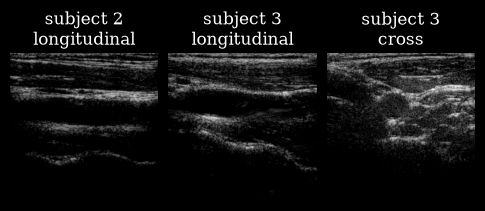

In [14]:
titles = [
    f"subject {subject_id}\n{view.split(' section')[0].lower()}"
    for subject_id, view in zip(
        metadata["metadata"]["subject"]["id"],
        metadata["metadata"]["annotations"]["view"],
    )
]

fig, _ = plot_image_grid(images, ncols=3, cmap="gray", vmin=-50, vmax=0, titles=titles)
loader.close()

## Summary

- Use `key="data/raw_data"` for channel data. The frame axis lands at `frame_axis=-1` by default;
  with `n_frames=1` that is a dummy axis you drop with `sample[..., 0]`, and for blocks
  `frame_axis=0` keeps the file's own layout.
- `axis_selections` filters axes at HDF5 read time. It always saves memory; whether it saves time
  depends on the file's chunking.
- `n_frames`, `frame_index_stride` and `overlapping_blocks` build temporal blocks out of
  consecutive frames.
- `return_metadata` returns a `(sample, metadata)` tuple. A list of dotted paths adds fields from
  the file, shaped like the zea file spec, with the loader's bookkeeping under `"file"`. Metadata is
  read once per file, and per-frame fields are sliced to match the sample.
- `file_filter` drops whole files by their content before indexing.
- Nothing here was downloaded in full: `hf://` paths stream the chunks each sample touches, and
  cache them on disk for the next read.

See the [`Dataloader` API reference](../../_autosummary/zea.data.dataloader.rst) for the full set of
arguments.